In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import warnings
warnings.simplefilter('ignore')

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os#Walking through directores

import plotly.graph_objects as go # Generate Graphs
from plotly.subplots import make_subplots #To Create Subplots

from sklearn import decomposition #pca
from sklearn.preprocessing import StandardScaler # Standardization ((X - X_mean)/X_std)

from sklearn.neighbors import KNeighborsClassifier #KNN Model
from sklearn.ensemble import RandomForestClassifier #RandomForest Model
from sklearn.linear_model import LogisticRegression #Logistic Model

from sklearn.model_selection import train_test_split # Splitting into train and test

from sklearn.model_selection import GridSearchCV# Hyperparameter Tuning
from sklearn.model_selection import cross_val_score#cross validation score

from sklearn.metrics import classification_report # text report showing the main classification metrics
from sklearn.metrics import confusion_matrix #to get confusion_matirx

pd.set_option('display.max_columns', None)

In [3]:
missing_values = ['?', '--', ' ', 'NA', 'N/A', '-'] #Sometimes Missing Values are't in form of NaN
df = pd.read_csv('/content/drive/MyDrive/Data Mining/cardio_train.csv', delimiter = ';', na_values = missing_values)
print('There are Total {} datapoints in the dataset with {} Features listed as {}:'.format(df.shape[0], df.shape[1], df.columns.values))

There are Total 70000 datapoints in the dataset with 13 Features listed as ['id' 'age' 'gender' 'height' 'weight' 'ap_hi' 'ap_lo' 'cholesterol'
 'gluc' 'smoke' 'alco' 'active' 'cardio']:


In [4]:
features_with_null = [features for feature in df.columns if df[feature].isnull().sum()>0]
if features_with_null:
    print('Features with Null Values {}'.format(features_with_null))
else:
    print('Dataset contains no Null Values')

Dataset contains no Null Values


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [6]:
df.drop(columns=['id'], inplace=True)

In [7]:
duplicate_sum = df.duplicated().sum()
if duplicate_sum:
    print('Duplicates Rows in Dataset are : {}'.format(duplicate_sum))
else:
    print('Dataset contains no Duplicate Values')

Duplicates Rows in Dataset are : 24


In [8]:
duplicated = df[df.duplicated(keep=False)]
duplicated = duplicated.sort_values(by=['gender', 'height', 'weight'], ascending= False)
duplicated.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
10494,16937,2,170,70.0,120,80,1,1,0,0,0,0
44653,16937,2,170,70.0,120,80,1,1,0,0,0,0
1142,17493,2,169,74.0,120,80,1,1,0,0,1,1
50432,17493,2,169,74.0,120,80,1,1,0,0,1,1
32683,17535,2,165,65.0,120,80,1,1,0,0,1,0


In [9]:
df.drop_duplicates(keep = 'first', inplace = True)
print('Total {} datapoints remaining with {} features'.format(df.shape[0], df.shape[1]))

Total 69976 datapoints remaining with 12 features


# Continuous Value

In [10]:
Continuous_features = [feature for feature in df.columns if len(df[feature].unique())>25]
print('Continuous Values are : {}'.format(Continuous_features))

Continuous Values are : ['age', 'height', 'weight', 'ap_hi', 'ap_lo']


In [11]:
df[Continuous_features].head()

,age,height,weight,ap_hi,ap_lo
0,18393,168,62.0,110,80
1,20228,156,85.0,140,90
2,18857,165,64.0,130,70
3,17623,169,82.0,150,100
4,17474,156,56.0,100,60


In [12]:
df[Continuous_features].describe()

,age,height,weight,ap_hi,ap_lo
count,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000
mean,19468.950126,164.359152,74.208519,128.820453,96.636261
std,2467.374620,8.211218,14.397211,154.037729,188.504581
min,10798.000000,55.000000,10.000000,-150.000000,-70.000000
25%,17664.000000,159.000000,65.000000,120.000000,80.000000
50%,19703.000000,165.000000,72.000000,120.000000,80.000000
75%,21327.000000,170.000000,82.000000,140.000000,90.000000
max,23713.000000,250.000000,200.000000,16020.000000,11000.000000


In [13]:
fig = go.Figure()

fig.add_trace(go.Box(x=df['height'], name = 'Height', boxpoints='outliers',))
fig.add_trace(go.Box(x=df['weight'], name = 'Weight', boxpoints='outliers',))

fig.update_layout(title_text="Box Plot for Weight and Height with Outliers")
fig.show()

In [14]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("Height Distribution", "Weight Distribution"))

trace0 = go.Histogram(x=df['height'], name = 'Height')
trace1 = go.Histogram(x=df['weight'], name = 'Weight')


fig.append_trace(trace0, 1, 1)
fig.append_trace(trace1, 1, 2)

fig.update_xaxes(title_text="Height", row=1, col=1)
fig.update_yaxes(title_text="Total Count", row=1, col=1)

fig.update_xaxes(title_text="Weight", row=1, col=2)
fig.update_yaxes(title_text="Total Count", row=1, col=2)

fig.update_layout(title_text="Histograph", height=700)


fig.show()

In [15]:
def outliers(df_out, drop = False):
    for each_feature in df_out.columns:
        feature_data = df_out[each_feature]
        Q1 = np.percentile(feature_data, 25.) # 25th percentile of the data of the given feature
        Q3 = np.percentile(feature_data, 75.) # 75th percentile of the data of the given feature
        IQR = Q3-Q1 #Interquartile Range
        outlier_step = IQR * 1.5 #That's we were talking about above
        outliers = feature_data[~((feature_data >= Q1 - outlier_step) & (feature_data <= Q3 + outlier_step))].index.tolist()
        print('For the feature {}, No of Outliers is {}'.format(each_feature, len(outliers)))
outliers(df[['height', 'weight']])

For the feature height, No of Outliers is 519
For the feature weight, No of Outliers is 1819


In [17]:
outline_free_df = df.copy()
outline_free_df[['height', 'weight']] = np.log(outline_free_df[['height', 'weight']])
outliers(outline_free_df[['height', 'weight']])

outline_free_df = outline_free_df[(outline_free_df['weight'] > outline_free_df['weight'].quantile(0.005)) & (outline_free_df['weight'] < outline_free_df['weight'].quantile(0.995))]
outline_free_df = outline_free_df[(outline_free_df['height'] > outline_free_df['height'].quantile(0.005)) & (outline_free_df['height'] < outline_free_df['height'].quantile(0.995))]
outliers(outline_free_df[['height', 'weight']])

For the feature height, No of Outliers is 484
For the feature weight, No of Outliers is 1174
For the feature height, No of Outliers is 0
For the feature weight, No of Outliers is 349


In [18]:
print('Handling outliners cost us {} datapoints'.format(len(df)-len(outline_free_df)))

Handling outliners cost us 1630 datapoints


## for ap_hi&ap_lo

In [19]:
outline_free_df = outline_free_df[outline_free_df['ap_lo']>=0]
outline_free_df = outline_free_df[outline_free_df['ap_hi']>=0]

In [20]:
print('There are total {} observations where ap_hi < ap_lo'.format(len(outline_free_df[outline_free_df['ap_hi'] < outline_free_df['ap_lo']])))

There are total 1182 observations where ap_hi < ap_lo


In [21]:
cleaned_data = outline_free_df[outline_free_df['ap_hi'] >= outline_free_df['ap_lo']].reset_index(drop=True)
print('Total observations preserved : {}'.format(len(cleaned_data)))

Total observations preserved : 67156


In [22]:
print('As per our assumptions we have total {} outliers'.format(len(cleaned_data[(cleaned_data["ap_hi"]>250) | (cleaned_data["ap_lo"]>200)])))

As per our assumptions we have total 38 outliers


In [23]:
cleaned_data = cleaned_data[(cleaned_data["ap_hi"]<=250) & (cleaned_data["ap_lo"]<=200)]

In [24]:
print('Total {} datapoints remaining with {} features'.format(cleaned_data.shape[0], cleaned_data.shape[1]))

Total 67118 datapoints remaining with 12 features


In [25]:
path = '/content/drive/MyDrive/Data Mining/cleandata.csv'
with open(path, 'w', encoding = 'utf-8-sig') as f:
  cleaned_data.to_csv(f)

# Data Conversion(Attribute Adjusting)

In [26]:
cleaned_data.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,5.123964,4.127134,110,80,1,1,0,0,1,0
1,20228,1,5.049856,4.442651,140,90,3,1,0,0,1,1
2,18857,1,5.105945,4.158883,130,70,3,1,0,0,0,1
3,17623,2,5.129899,4.406719,150,100,1,1,0,0,1,1
4,17474,1,5.049856,4.025352,100,60,1,1,0,0,0,0


In [27]:
cleaned_data['age'] = cleaned_data['age'].div(365).apply(lambda x: int(x))

In [28]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=cleaned_data['age'], name = 'Age'))
fig.show()

In [29]:
duplicate_sum = cleaned_data.duplicated().sum()
if duplicate_sum:
    print('Duplicates Rows in Dataset are : {}'.format(duplicate_sum))
else:
    print('Dataset contains no Duplicate Values')

Duplicates Rows in Dataset are : 3180


In [30]:
duplicated = cleaned_data[cleaned_data.duplicated(keep=False)]
duplicated = duplicated.sort_values(by=['gender', 'height', 'weight'], ascending= False)
duplicated.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
22272,57,2,5.192957,4.605170,120,80,1,1,0,0,1,0
58984,57,2,5.192957,4.605170,120,80,1,1,0,0,1,0
9953,40,2,5.192957,4.382027,120,80,1,1,0,0,1,0
20350,56,2,5.192957,4.382027,150,90,1,1,0,0,1,1
28371,56,2,5.192957,4.382027,150,90,1,1,0,0,1,1


In [31]:
cleaned_data.drop_duplicates(keep = 'first', inplace = True)
print('Total {} datapoints remaining with {} features'.format(cleaned_data.shape[0], df.shape[1]))

Total 63938 datapoints remaining with 12 features


In [32]:
fig = go.Figure(data=[go.Bar(x = cleaned_data[cleaned_data['cardio'] == 0]['age'].value_counts().index.to_list(),
                             y =cleaned_data[cleaned_data['cardio'] == 0]['age'].value_counts().values, name = 'Non CVD'),
                      go.Bar(x = cleaned_data[cleaned_data['cardio'] == 1]['age'].value_counts().index.to_list(),
                             y =cleaned_data[cleaned_data['cardio'] == 1]['age'].value_counts().values, name = 'CVD')]
               )

fig.update_layout(barmode='group', xaxis_tickangle=-45, title_text="Distribution of Age groups grouped by Target Value",
                  yaxis=dict(
        title='Total Count',
        titlefont_size=16,
        tickfont_size=14,
    ),     xaxis=dict(
        title='Age',
        titlefont_size=16,
        tickfont_size=14,
    ))
fig.show()

In [32]:
fig = go.Figure([go.Pie(labels=cleaned_data[cleaned_data['cardio'] == 0]['age'].value_counts().index.to_list(),values=cleaned_data[cleaned_data['cardio'] == 0]['age'].value_counts().values)])
fig.update_layout(title_text="Distribution of Age group for Non CVD", template="plotly_white")
fig.data[0].marker.line.color = 'rgb(255, 255, 255)'
fig.data[0].marker.line.width = 2
fig.update_traces(textposition='inside')
fig.show()

In [33]:
fig = go.Figure([go.Pie(labels=cleaned_data[cleaned_data['cardio'] == 1]['age'].value_counts().index.to_list(),values=cleaned_data[cleaned_data['cardio'] == 1]['age'].value_counts().values)])
fig.update_layout(title_text="Distribution of Age group for CVD", template="plotly_white")
fig.data[0].marker.line.color = 'rgb(255, 255, 255)'
fig.data[0].marker.line.width = 2
fig.update_traces(textposition='inside')
fig.show()

In [33]:
fig = make_subplots(rows=2, cols=2, subplot_titles=("Height Distribution for CVD Population", "Height Distribution for non CVD Population", "Weight Distribution for CVD Population", "Weight Distribution for non CVD Population"))

trace0 = go.Histogram(x=np.exp(cleaned_data[cleaned_data['cardio'] == 0]['height']), name = 'Non CVD')
trace1 = go.Histogram(x=np.exp(cleaned_data[cleaned_data['cardio'] == 1]['height']), name = 'CVD')

trace2 = go.Histogram(x=np.exp(cleaned_data[cleaned_data['cardio'] == 0]['weight']), name = 'Non CVD')
trace3 = go.Histogram(x=np.exp(cleaned_data[cleaned_data['cardio'] == 1]['weight']), name = 'CVD')

fig.append_trace(trace0, 1, 1)
fig.append_trace(trace1, 1, 2)
fig.append_trace(trace2, 2, 1)
fig.append_trace(trace3, 2, 2)

fig.update_xaxes(title_text="Height", row=1, col=1)
fig.update_yaxes(title_text="Total Count", row=1, col=1)

fig.update_xaxes(title_text="Height", row=1, col=2)
fig.update_yaxes(title_text="Total Count", row=1, col=2)

fig.update_xaxes(title_text="Weight", row=2, col=1)
fig.update_yaxes(title_text="Total Count", row=2, col=1)

fig.update_xaxes(title_text="Weight", row=2, col=2)
fig.update_yaxes(title_text="Total Count", row=2, col=2)

fig.show()

In [35]:
fig = go.Figure(data=[go.Bar(x = cleaned_data[cleaned_data['cardio'] == 0]['ap_hi'].value_counts().index.to_list(),
                             y =cleaned_data[cleaned_data['cardio'] == 0]['ap_hi'].value_counts().values, name = 'Non CVD'),
                      go.Bar(x = cleaned_data[cleaned_data['cardio'] == 1]['ap_hi'].value_counts().index.to_list(),
                             y =cleaned_data[cleaned_data['cardio'] == 1]['ap_hi'].value_counts().values, name = 'CVD')]
               )

fig.update_layout(barmode='group', xaxis_tickangle=-45, title_text="Distribution of Systolic blood pressure Values grouped by Target Value",
                  yaxis=dict(
        title='Total Count',
        titlefont_size=16,
        tickfont_size=14,
    ),     xaxis=dict(title='Systolic Blood Pressure Values',
        titlefont_size=16,
        tickfont_size=14,
    ))
fig.show()

In [36]:
fig = go.Figure([go.Pie(labels=cleaned_data[cleaned_data['cardio'] == 0]['ap_hi'].value_counts().index.to_list(),values=cleaned_data[cleaned_data['cardio'] == 0]['ap_hi'].value_counts().values)])
fig.update_layout(title_text="Distribution of Systolic blood pressure values for Non CVD", template="plotly_white")
fig.data[0].marker.line.color = 'rgb(255, 255, 255)'
fig.data[0].marker.line.width = 2
fig.update_traces(textposition='inside')
fig.show()

In [37]:
fig = go.Figure([go.Pie(labels=cleaned_data[cleaned_data['cardio'] == 1]['ap_hi'].value_counts().index.to_list(),values=cleaned_data[cleaned_data['cardio'] == 1]['ap_hi'].value_counts().values)])
fig.update_layout(title_text="Distribution of Systolic blood pressure values for CVD", template="plotly_white")
fig.data[0].marker.line.color = 'rgb(255, 255, 255)'
fig.data[0].marker.line.width = 2
fig.update_traces(textposition='inside')
fig.show()

In [38]:
fig = go.Figure(data=[go.Bar(x = cleaned_data[cleaned_data['cardio'] == 0]['ap_lo'].value_counts().index.to_list(),
                             y =cleaned_data[cleaned_data['cardio'] == 0]['ap_lo'].value_counts().values, name = 'Non CVD'),
                      go.Bar(x = cleaned_data[cleaned_data['cardio'] == 1]['ap_lo'].value_counts().index.to_list(),
                             y =cleaned_data[cleaned_data['cardio'] == 1]['ap_lo'].value_counts().values, name = 'CVD')]
               )

fig.update_layout(barmode='group', xaxis_tickangle=-45, title_text="Distribution of Diastolic blood pressure Values grouped by Target Value",
        yaxis=dict(
        title='Total Count',
        titlefont_size=16,
        tickfont_size=14,
    ),     xaxis=dict(
        title='Diastolic Blood Pressure Values',
        titlefont_size=16,
        tickfont_size=14,
    ))
fig.show()

In [39]:
fig = go.Figure([go.Pie(labels=cleaned_data[cleaned_data['cardio'] == 0]['ap_lo'].value_counts().index.to_list(),values=cleaned_data[cleaned_data['cardio'] == 0]['ap_lo'].value_counts().values)])
fig.update_layout(title_text="Distribution of Daistolic blood pressure values for Non CVD", template="plotly_white")
fig.data[0].marker.line.color = 'rgb(255, 255, 255)'
fig.data[0].marker.line.width = 2
fig.update_traces(textposition='inside')
fig.show()

In [40]:
fig = go.Figure([go.Pie(labels=cleaned_data[cleaned_data['cardio'] == 1]['ap_lo'].value_counts().index.to_list(),values=cleaned_data[cleaned_data['cardio'] == 1]['ap_lo'].value_counts().values)])
fig.update_layout(title_text="Distribution of Daistolic blood pressure values for CVD", template="plotly_white")
fig.data[0].marker.line.color = 'rgb(255, 255, 255)'
fig.data[0].marker.line.width = 2
fig.update_traces(textposition='inside')
fig.show()

## Nominal/Ordinal Data

In [34]:
Categorial_features = [feature for feature in cleaned_data.columns if len(cleaned_data[feature].unique())<25]
print('Categorial Values are : {}'.format(Categorial_features))

Categorial Values are : ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


In [35]:
for each_feature in Categorial_features:
    print('No of Categorial Values in Feature {} is {} as {}'.format(each_feature, len(cleaned_data[each_feature].unique()), cleaned_data[each_feature].unique()))

No of Categorial Values in Feature gender is 2 as [2 1]
No of Categorial Values in Feature cholesterol is 3 as [1 3 2]
No of Categorial Values in Feature gluc is 3 as [1 2 3]
No of Categorial Values in Feature smoke is 2 as [0 1]
No of Categorial Values in Feature alco is 2 as [0 1]
No of Categorial Values in Feature active is 2 as [1 0]
No of Categorial Values in Feature cardio is 2 as [0 1]


In [36]:
fig = go.Figure([go.Pie(labels=['Not Having CVD', 'Having CVD'],values=cleaned_data['cardio'].value_counts().values)])
fig.update_layout(title_text="Pie chart of Target Variable", template="plotly_white")
fig.data[0].marker.line.color = 'rgb(255, 255, 255)'
fig.data[0].marker.line.width = 2
fig.update_traces(hole=.4,)
fig.show()

In [37]:
fig = make_subplots(rows=2, cols=3,subplot_titles=("Alchoal Distribution", "Gender Distribution", "Choslesterol Distribution", "Glucose Distribution", "Smoking Distribution", "Fitness Distribution"), specs=[[{'type':'domain'}, {'type':'domain'}, {'type':'domain'}], [{'type':'domain'}, {'type':'domain'}, {'type':'domain'}]])

fig.add_trace(go.Pie(labels=['Non Alchoalic', 'Alchoalic'],values=cleaned_data['alco'].value_counts().values, name = 'Alchoal Status'), 1, 1)
fig.add_trace(go.Pie(labels=['Female', 'Male'],values=cleaned_data['gender'].value_counts().values, name = 'Gender Status'), 1, 2)

fig.add_trace(go.Pie(labels=['Normal', 'Above Normal', 'Well Above Normal'],values=cleaned_data['cholesterol'].value_counts().values, name = 'Cholesterol Level Status'), 1, 3)
fig.add_trace(go.Pie(labels=['Normal', 'Above Normal', 'Well Above Normal'],values=cleaned_data['gluc'].value_counts().values, name = 'Glucose Level Status'), 2, 1)

fig.add_trace(go.Pie(labels=['Non Smoker', 'Smoker'],values=cleaned_data['smoke'].value_counts().values, name = 'Smoking Status'), 2, 2)
fig.add_trace(go.Pie(labels=['Not Involved in Physical Activites', 'Involved in Physical Activites'],values=cleaned_data['active'].value_counts().values, name = 'Fitness Status'), 2, 3)

fig.update_traces(hole=.4,)
fig.update_layout(title_text="Distribution of Various Categorial Values")

fig.show()


## Generate BMI Attribute

In [38]:
def BMI(data):
    return np.exp(data['weight']) / (np.exp(data['height'])/100)**2

cleaned_data['bmi'] = cleaned_data.apply(BMI, axis=1)

In [41]:
def pulse(data):
    return np.subtract(data['ap_hi'], data['ap_lo'])

cleaned_data['pulse'] = cleaned_data.apply(pulse, axis=1)
path = '/content/drive/MyDrive/Data Mining/cleaned_data_yearsBMI.csv'
with open(path, 'w', encoding = 'utf-8-sig') as f:
  cleaned_data.to_csv(f)

## build up a heat map to get to know about correlation between variables

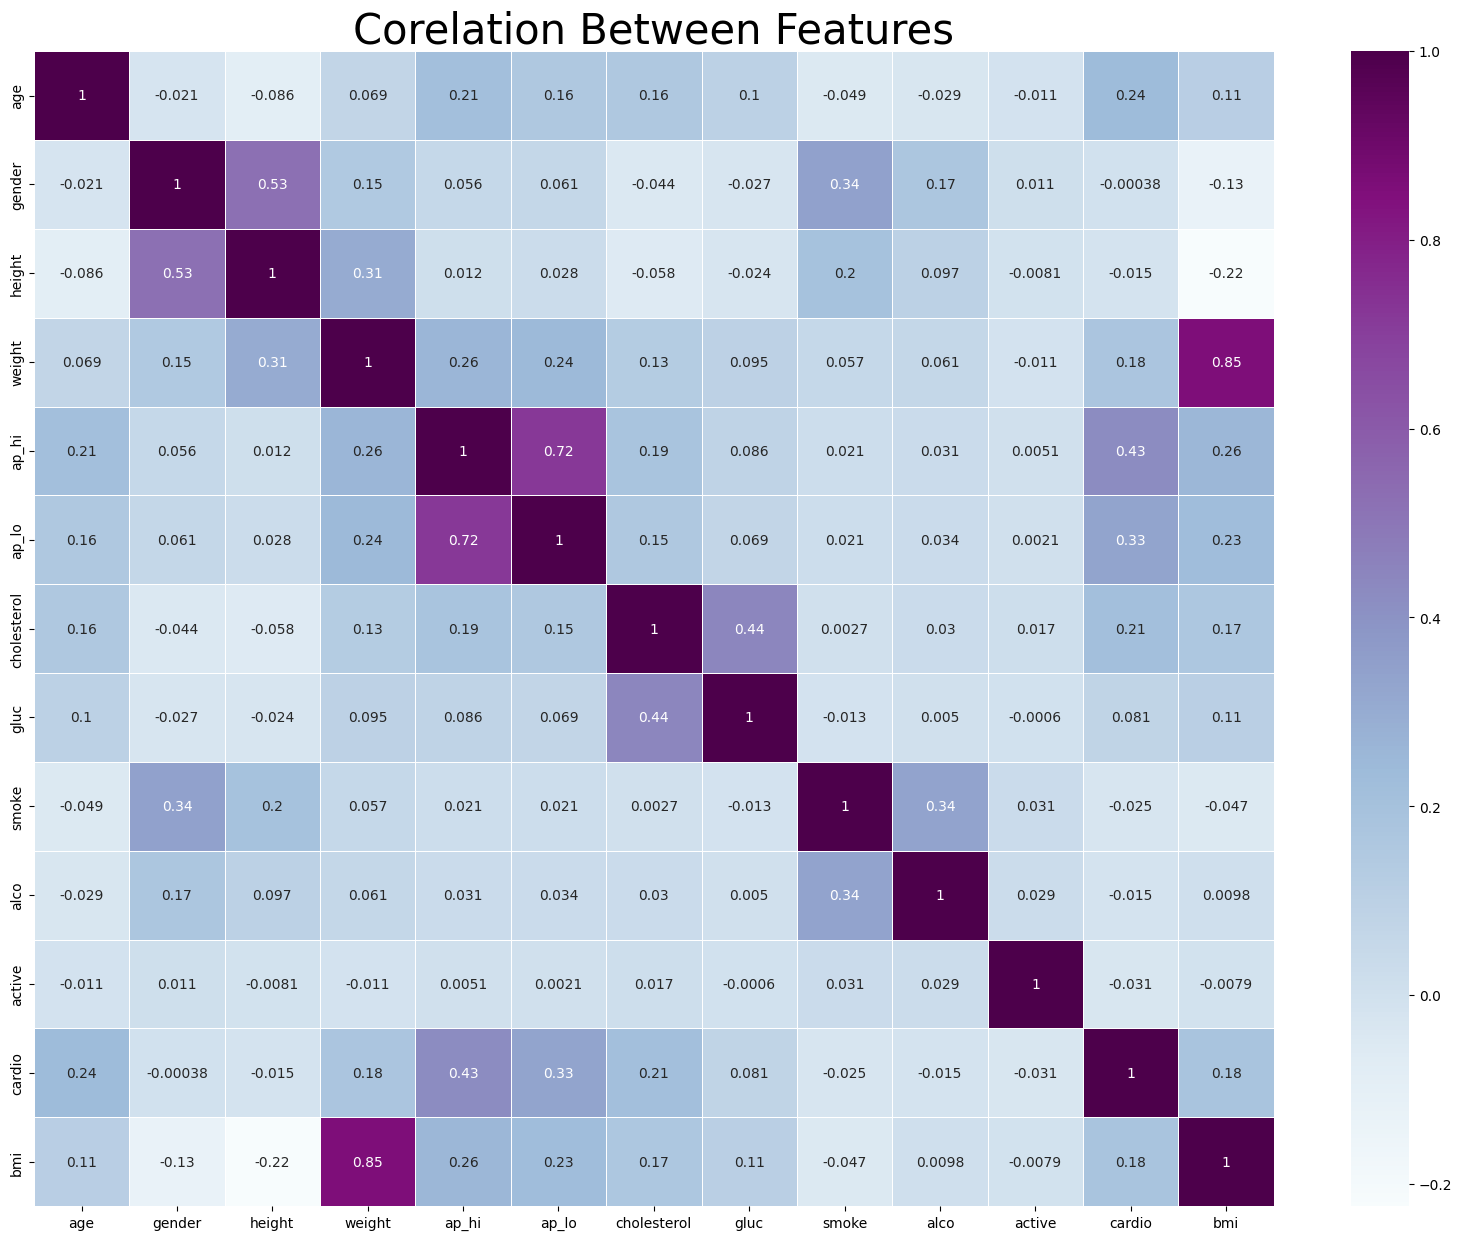

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

missing_values = ['?', '--', ' ', 'NA', 'N/A', '-']
df = pd.read_csv('/content/drive/MyDrive/Data Mining/cleaned_data_yearsBMI_2.csv', delimiter = ',', na_values = missing_values)
plt.rcParams['figure.figsize'] = (20, 15)
sns.heatmap(df.corr(), annot = True, linewidths=.5, cmap="BuPu")
plt.title('Corelation Between Features', fontsize = 30)
plt.show()

In [10]:
#X = cleaned_data.drop(['cardio', 'bmi', 'weight', 'gluc', 'gender', 'smoke', 'alco', 'active'], axis =1)
#Y = cleaned_data['cardio']
X = df.drop(['cardio', 'bmi', 'weight', 'gluc', 'gender', 'smoke', 'alco', 'active', 'height'], axis =1)
Y = df['cardio']

In [11]:
path = '/content/drive/MyDrive/Data Mining/Cardio_processed_3.csv'
with open(path, 'w', encoding = 'utf-8-sig') as f:
  X.to_csv(f)

## Data Scaling

In [12]:
scaler = StandardScaler()
standard_X = scaler.fit_transform(X)

In [13]:
standard_X
path = '/content/drive/MyDrive/Data Mining/trainingdata.csv'
with open(path, 'w', encoding = 'utf-8-sig') as f:
  standard_X.to_csv(f)

array([[-0.4194714 , -1.00203435, -0.13609483, -0.55135331],
       [ 0.31577879,  0.77010111,  0.88587113,  2.35366751],
       [-0.27242136,  0.17938929, -1.15806079,  2.35366751],
       ...,
       [-0.12537132,  3.13294838,  0.88587113,  2.35366751],
       [ 1.19807902,  0.4747452 , -0.13609483, -0.55135331],
       [ 0.46282883, -0.41132253, -0.13609483,  0.9011571 ]])

In [14]:
X.head()

,age,ap_hi,ap_lo,cholesterol
0,50,110,80,1
1,55,140,90,3
2,51,130,70,3
3,48,150,100,1
4,47,100,60,1


# Model Training

In [15]:
X_train, X_test, y_train, y_test = train_test_split(standard_X, Y, test_size=0.25, random_state=42, shuffle = True)

## k-NN

In [16]:
params = {'n_neighbors':list(range(0, 50)),
          'weights':['uniform', 'distance'],
          'p':[1,2]}

knn = KNeighborsClassifier()
knn_grid_cv = GridSearchCV(knn, param_grid=params, cv=10)
knn_grid_cv.fit(X_train, y_train)
print("Best Hyper Parameters:\n",knn_grid_cv.best_params_)

Best Hyper Parameters:
 {'n_neighbors': 42, 'p': 1, 'weights': 'uniform'}


## Random Forest

In [ ]:
params = {
    'n_estimators': [10, 50, 100, 150, 200, 300, 400, 500],
    'max_depth' : [10,20,30,40,50],
    'criterion' : ['entropy','gini']
}

rfc_gridcv = RandomForestClassifier(random_state=42)
rfc_gridcv = GridSearchCV(estimator=rfc_gridcv, param_grid=params, cv= 10, n_jobs = -1)
rfc_gridcv.fit(X_train, y_train)
print("Best Hyper Parameters:\n",rfc_gridcv.best_params_)

## Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto'],
}

svm_classifier = SVC(random_state=42)
grid_search = GridSearchCV(svm_classifier, param_grid, cv=10)
grid_search.fit(X_train, y_train)
print("Best Hyper Parameters:\n",grid_search.best_params_)

## XGBoost

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

xgb_classifier = xgb.XGBClassifier(random_state=42)
xgb_classifier.fit(X_train, y_train)
y_pred_xgb = xgb_classifier.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb * 100:.2f}%")

# Model Evaluation

## Evaluate kNN

In [ ]:
scores = cross_val_score(knn, X_train, y_train, cv=10)
print('KNN Model gives an average accuracy of {0:.2f} % with minimun of {1:.2f} % and maximum of {2:.2f} % accuracy'.format(scores.mean() * 100, scores.min() * 100, scores.max() * 100))

In [ ]:
Y_hat = knn.predict(X_test)
print(classification_report(y_test, Y_hat))

In [ ]:
plt.rcParams['figure.figsize'] = (5, 5)
sns.heatmap(confusion_matrix(y_test, Y_hat), annot = True, linewidths=.5, cmap="YlGnBu")
plt.title('Corelation Between Features')
plt.show()

In [ ]:
print('True Positive Cases : {}'.format(confusion_matrix(y_test, Y_hat)[1][1]))
print('True Negative Cases : {}'.format(confusion_matrix(y_test, Y_hat)[0][0]))
print('False Positive Cases : {}'.format(confusion_matrix(y_test, Y_hat)[0][1]))
print('False Negative Cases : {}'.format(confusion_matrix(y_test, Y_hat)[1][0]))

## Evaluate RandomForest

In [ ]:
scores = cross_val_score(rfc, X_train, y_train, cv=10)
print('Random Forest Model gives an average accuracy of {0:.2f} % with minimun of {1:.2f} % and maximum of {2:.2f} % accuracy'.format(scores.mean() * 100, scores.min() * 100, scores.max() * 100))

In [ ]:
Y_hat = rfc.predict(X_test)
print(classification_report(y_test, Y_hat))

In [ ]:
plt.rcParams['figure.figsize'] = (5, 5)
sns.heatmap(confusion_matrix(y_test, Y_hat), annot = True, linewidths=.5, cmap="YlGnBu")
plt.title('Corelation Between Features')
plt.show()

In [ ]:
print('True Positive Cases : {}'.format(confusion_matrix(y_test, Y_hat)[1][1]))
print('True Negative Cases : {}'.format(confusion_matrix(y_test, Y_hat)[0][0]))
print('False Positive Cases : {}'.format(confusion_matrix(y_test, Y_hat)[0][1]))
print('False Negative Cases : {}'.format(confusion_matrix(y_test, Y_hat)[1][0]))

## Evaluate SVM

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

# Assuming grid_search is your trained GridSearchCV object

# Step 1: Get the best SVM model from the grid search
best_svm_model = grid_search.best_estimator_

# Step 2: Evaluate the model using cross-validation
cv_scores = cross_val_score(best_svm_model, X_train, y_train, cv=10, scoring='accuracy')

# Step 3: Print the average accuracy and other statistics
print('SVM Model gives an average accuracy of {0:.2f}% with minimum of {1:.2f}% and maximum of {2:.2f}% accuracy'.format(
    cv_scores.mean() * 100, cv_scores.min() * 100, cv_scores.max() * 100))

# Step 4: Make predictions on the test set
y_pred_svm = best_svm_model.predict(X_test)

# Step 5: Print classification report
print("Classification Report:\n", classification_report(y_test, y_pred_svm))


In [ ]:
plt.rcParams['figure.figsize'] = (5, 5)
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot = True, linewidths=.5, cmap="YlGnBu")
plt.title('Corelation Between Features')
plt.show()

In [ ]:
print('True Positive Cases : {}'.format(confusion_matrix(y_test, Y_hat)[1][1]))
print('True Negative Cases : {}'.format(confusion_matrix(y_test, Y_hat)[0][0]))
print('False Positive Cases : {}'.format(confusion_matrix(y_test, Y_hat)[0][1]))
print('False Negative Cases : {}'.format(confusion_matrix(y_test, Y_hat)[1][0]))

## Evaluate XGBoost

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

# Assuming xgb_classifier is your trained XGBClassifier

# Step 1: Evaluate the model using cross-validation
cv_scores_xgb = cross_val_score(xgb_classifier, X_train, y_train, cv=10, scoring='accuracy')

# Step 2: Print the average accuracy and other statistics
print('XGBoost Model gives an average accuracy of {0:.2f}% with minimum of {1:.2f}% and maximum of {2:.2f}% accuracy'.format(
    cv_scores_xgb.mean() * 100, cv_scores_xgb.min() * 100, cv_scores_xgb.max() * 100))

# Step 3: Make predictions on the test set
y_pred_xgb = xgb_classifier.predict(X_test)

# Step 4: Print classification report
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

In [ ]:
plt.rcParams['figure.figsize'] = (5, 5)
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot = True, linewidths=.5, cmap="YlGnBu")
plt.title('Corelation Between Features')
plt.show()

In [ ]:
print('True Positive Cases : {}'.format(confusion_matrix(y_test, Y_hat)[1][1]))
print('True Negative Cases : {}'.format(confusion_matrix(y_test, Y_hat)[0][0]))
print('False Positive Cases : {}'.format(confusion_matrix(y_test, Y_hat)[0][1]))
print('False Negative Cases : {}'.format(confusion_matrix(y_test, Y_hat)[1][0]))